# Sarcasm Detection in News Headlines using RNN, LSTM, and Word2Vec Embeddings

**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Author:** Prajon Acharya
**Student ID:** 2432719  
**Tutor:** Mr. Bijaya Ghimire  


---
## Section 0: Environment Setup

In [12]:
# Install required packages
# numpy is pinned to 1.23.5 for gensim compatibility as noted in the assignment appendix
!pip install -q numpy==1.23.5
!pip install -q gensim
!pip install -q gradio
!pip install -q wordcloud
!pip install -q contractions
print("All packages installed.")

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
All packages installed.


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

TensorFlow version: 2.20.0
GPU available: []
Built with CUDA: True


In [15]:
#  Standard Library
import os
import re
import time
import random
import warnings
warnings.filterwarnings('ignore')

#  Numerical & Data
import numpy as np
import pandas as pd
from collections import Counter

#  Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

#  NLP Preprocessing
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

#  Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#  Keras / TensorFlow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

#  Gensim (Word2Vec / GloVe)
import gensim.downloader as gensim_api

#  Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All imports successful.")

All imports successful.


---
## Section 1: Dataset Loading and Exploratory Data Analysis

In [16]:
# Dataset path
DATASET_PATH = "/content/drive/MyDrive/sarcastic_headlines.csv"

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (28619, 2)

First 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [17]:
# Keep only the two relevant columns
df = df[['headline', 'is_sarcastic']].copy()

print("Columns:", df.columns.tolist())
print("\nNull values:")
print(df.isnull().sum())

df.dropna(inplace=True)

print(f"\nTotal samples after removing nulls: {len(df)}")
print("\nClass distribution:")
print(df['is_sarcastic'].value_counts())
print("\n  0 = Not Sarcastic")
print("  1 = Sarcastic")

Columns: ['headline', 'is_sarcastic']

Null values:
headline        0
is_sarcastic    0
dtype: int64

Total samples after removing nulls: 28619

Class distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

  0 = Not Sarcastic
  1 = Sarcastic


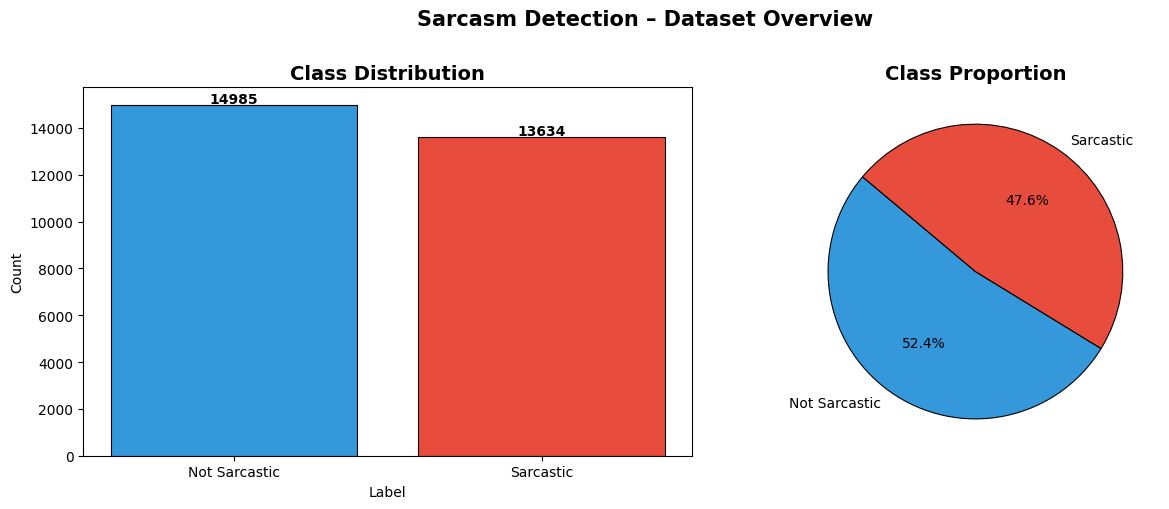

Observation: The dataset is roughly balanced between sarcastic and non-sarcastic headlines.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

label_counts = df['is_sarcastic'].value_counts().sort_index()
label_names  = ['Not Sarcastic', 'Sarcastic']
colors       = ['#3498DB', '#E74C3C']

# Bar chart
axes[0].bar(label_names, label_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, cnt in enumerate(label_counts.values):
    axes[0].text(i, cnt + 80, str(cnt), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=label_names,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Sarcasm Detection – Dataset Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Observation: The dataset is roughly balanced between sarcastic and non-sarcastic headlines.")

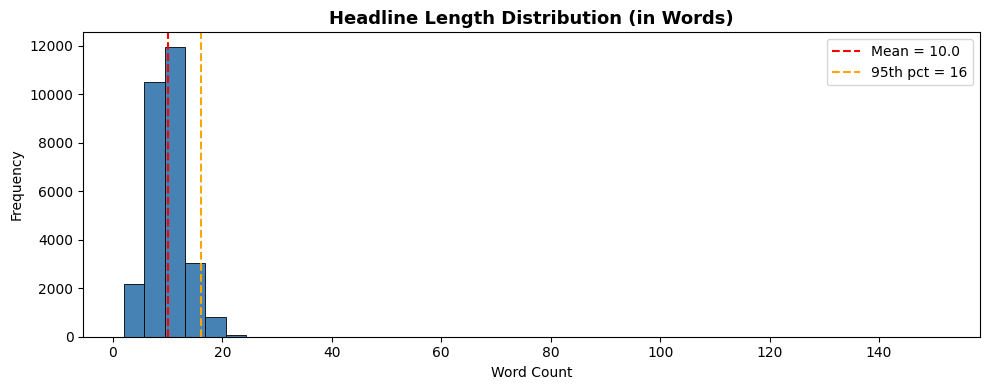

Min words : 2
Max words : 151
Mean words: 10.0
95th pct  : 16


In [19]:
# Headline-length distribution
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['word_count'], bins=40, color='steelblue', edgecolor='black', linewidth=0.6)
ax.axvline(df['word_count'].mean(), color='red', linestyle='--',
           label=f"Mean = {df['word_count'].mean():.1f}")
ax.axvline(np.percentile(df['word_count'], 95), color='orange', linestyle='--',
           label=f"95th pct = {np.percentile(df['word_count'], 95):.0f}")
ax.set_title('Headline Length Distribution (in Words)', fontsize=13, fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min words : {df['word_count'].min()}")
print(f"Max words : {df['word_count'].max()}")
print(f"Mean words: {df['word_count'].mean():.1f}")
print(f"95th pct  : {np.percentile(df['word_count'], 95):.0f}")

---
## Section 2: Text Preprocessing, Tokenization, and Sequence Padding

In [20]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_headline(text: str) -> str:
    """Full NLP preprocessing pipeline for a single news headline."""
    # 1. Lowercase
    text = text.lower()

    # 2. Expand contractions (e.g. "don't" → "do not")
    text = contractions.fix(text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 5. Remove #hashtags
    text = re.sub(r'#\w+', '', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 8. Tokenise, remove stopwords, and lemmatise
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOP_WORDS and len(w) > 1]

    return ' '.join(tokens)

# Apply preprocessing to every headline
df['clean_headline'] = df['headline'].apply(clean_headline)

print("Before:", df['headline'].iloc[0])
print("After :", df['clean_headline'].iloc[0])

Before: thirtysomething scientists unveil doomsday clock of hair loss
After : thirtysomething scientist unveil doomsday clock hair loss


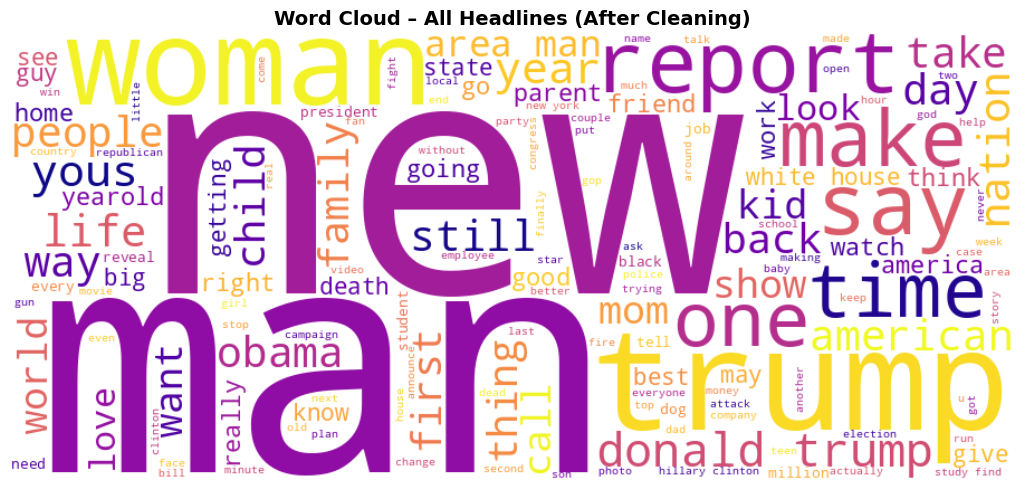

In [11]:
# Word cloud: entire corpus
all_words_str = ' '.join(df['clean_headline'].tolist())

wc_all = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='plasma',
    max_words=150
).generate(all_words_str)

plt.figure(figsize=(14, 5))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – All Headlines (After Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

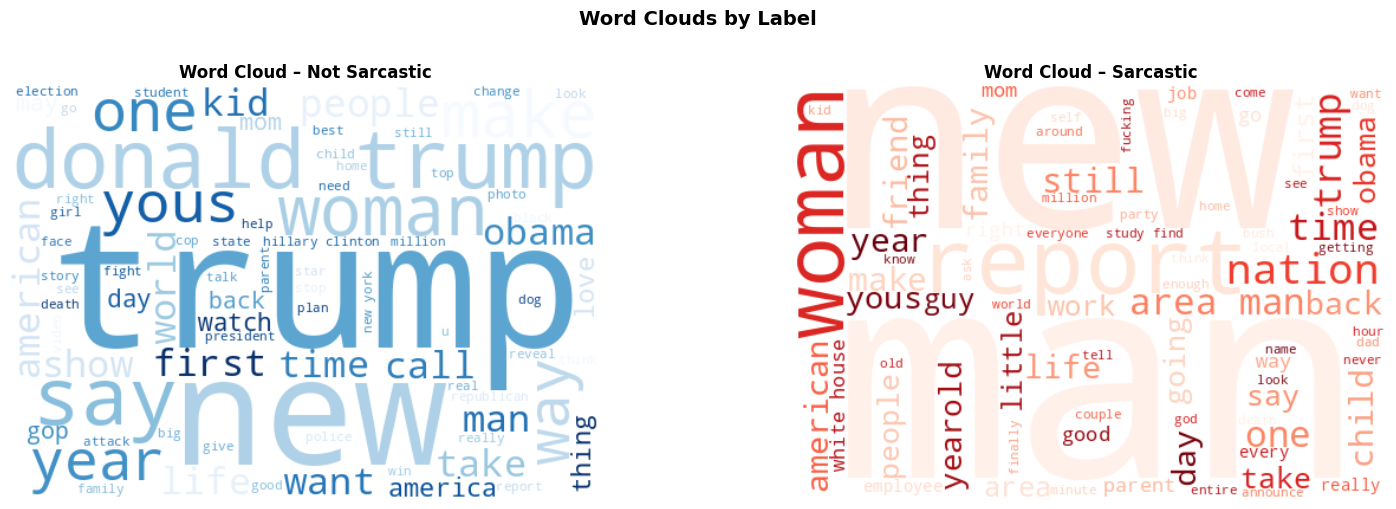

In [21]:
# Word cloud split by label: Not Sarcastic vs Sarcastic
class_color_maps = {0: 'Blues', 1: 'Reds'}
class_display    = {0: 'Not Sarcastic', 1: 'Sarcastic'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, label_val in zip(axes, [0, 1]):
    subset_text = ' '.join(
        df[df['is_sarcastic'] == label_val]['clean_headline'].tolist()
    )
    wc = WordCloud(
        width=500, height=350,
        background_color='white',
        colormap=class_color_maps[label_val],
        max_words=80
    ).generate(subset_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud – {class_display[label_val]}', fontsize=12, fontweight='bold')

plt.suptitle('Word Clouds by Label', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

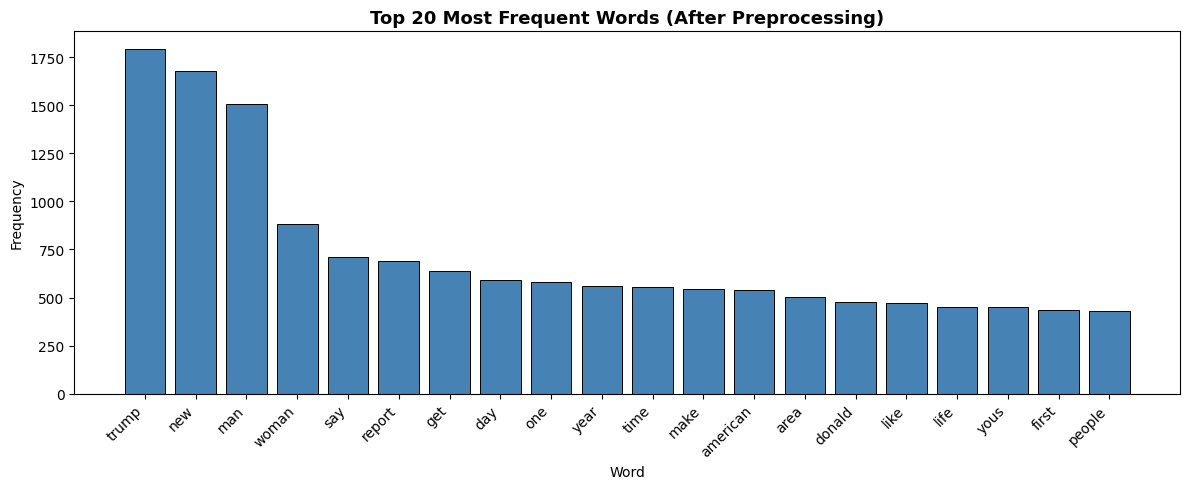

In [22]:
# Top-20 most frequent words across all cleaned headlines
all_tokens = ' '.join(df['clean_headline'].tolist()).split()
word_freq  = Counter(all_tokens).most_common(20)
top_words, top_freqs = zip(*word_freq)

plt.figure(figsize=(12, 5))
plt.bar(top_words, top_freqs, color='steelblue', edgecolor='black', linewidth=0.7)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words (After Preprocessing)', fontsize=13, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [23]:
# Binary labels: 0 = Not Sarcastic, 1 = Sarcastic
# is_sarcastic is already integer (0/1) — no LabelEncoder required
NUM_CLASSES = 2
CLASS_NAMES = ['Not Sarcastic', 'Sarcastic']

print("Number of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)
print("Label 0 →", CLASS_NAMES[0])
print("Label 1 →", CLASS_NAMES[1])

Number of classes: 2
Class names: ['Not Sarcastic', 'Sarcastic']
Label 0 → Not Sarcastic
Label 1 → Sarcastic


In [24]:
# 80/20 stratified train-test split
X = df['clean_headline'].values
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test     samples : {len(X_test)}")

Training samples : 22895
Test     samples : 5724


In [25]:
# Tokenise on training data only to prevent data leakage
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
print(f"Full vocabulary size  : {len(word_index)}")
print(f"Capped vocabulary size: {VOCAB_SIZE}")

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences  = tokenizer.texts_to_sequences(X_test)

Full vocabulary size  : 22514
Capped vocabulary size: 20000


In [26]:
# Percentile-based padding avoids excessively long sequences
train_seq_lengths = [len(s) for s in train_sequences]
MAX_LEN = int(np.percentile(train_seq_lengths, 95))
print(f"95th-percentile sequence length → MAX_LEN = {MAX_LEN}")

X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad  shape: {X_test_pad.shape}")

# One-hot encode for categorical cross-entropy
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

95th-percentile sequence length → MAX_LEN = 11
X_train_pad shape: (22895, 11)
X_test_pad  shape: (5724, 11)


---
## Section 3: Model Building

Three models are built and compared:
- **Model 1** – Simple RNN with a trainable Embedding layer  
- **Model 2** – LSTM with a trainable Embedding layer  
- **Model 3** – LSTM with pre-trained GloVe (Word2Vec) embeddings (weights frozen)

In [27]:

# Model 1: Simple RNN with Trainable Embedding

EMBEDDING_DIM = 128

rnn_model = Sequential(name='SimpleRNN_Model', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 2: LSTM with Trainable Embedding
# Stacked LSTM captures longer-range dependencies in headlines
# ─────────────────────────────────────────────────────────────────────────────
lstm_model = Sequential(name='LSTM_Model', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
    LSTM(64,  dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 3 – Step 1: Load Pre-trained GloVe embeddings
# glove-wiki-gigaword-100 is selected because our data is formal news text.
# Wikipedia + Gigaword corpus shares vocabulary with news headlines and
# provides richer semantic coverage for written English than social-media
# oriented embeddings.
# ─────────────────────────────────────────────────────────────────────────────
print("Downloading pre-trained GloVe Wiki-Gigaword embeddings (100-dim) ...")
print("This may take a few minutes on the first download.")

embedding_model = gensim_api.load('glove-wiki-gigaword-100')
W2V_DIM = 100

print(f"\nEmbedding model loaded. Vocabulary size: {len(embedding_model.key_to_index)}")

This may take a few minutes on the first download.
[==================================================] 100.0% 128.1/128.1MB downloaded

Embedding model loaded. Vocabulary size: 400000


In [30]:
# Build the embedding matrix: rows = word index, cols = GloVe vector
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        hits += 1
    else:
        misses += 1

coverage = hits / (hits + misses) * 100
print(f"Words found in GloVe   : {hits}")
print(f"Out-of-vocabulary words: {misses}")
print(f"Embedding coverage     : {coverage:.1f}%")
print(f"Embedding matrix shape : {embedding_matrix.shape}")

Words found in GloVe   : 17737
Out-of-vocabulary words: 2262
Embedding coverage     : 88.7%
Embedding matrix shape : (20000, 100)


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 3: LSTM with Pre-trained GloVe (Word2Vec) Embeddings
# trainable=False keeps pre-trained weights frozen during training
# ─────────────────────────────────────────────────────────────────────────────
lstm_w2v_model = Sequential(name='LSTM_Word2Vec_Model', layers=[
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=W2V_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
    LSTM(64,  dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_w2v_model.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

---
## Section 4: Model Training and Evaluation

In [32]:
OPTIMIZER  = 'adam'
LOSS       = 'categorical_crossentropy'
METRICS    = ['accuracy']
BATCH_SIZE = 64
EPOCHS     = 20

rnn_model.compile(optimizer=OPTIMIZER,      loss=LOSS, metrics=METRICS)
lstm_model.compile(optimizer=OPTIMIZER,     loss=LOSS, metrics=METRICS)
lstm_w2v_model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)

print("All models compiled.")

All models compiled.


In [33]:
def make_callbacks():
    """Return fresh EarlyStopping + ReduceLROnPlateau callbacks for each model."""
    return [
        EarlyStopping(
            monitor='val_loss', patience=4,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=2, min_lr=1e-6, verbose=1
        )
    ]

In [34]:
print("Training Model 1 – Simple RNN ...")
t0 = time.time()

history_rnn = rnn_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)

rnn_train_time = time.time() - t0
print(f"\nModel 1 training time: {rnn_train_time:.1f}s")

Training Model 1 – Simple RNN ...
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.7277 - loss: 0.5242 - val_accuracy: 0.8049 - val_loss: 0.4430 - learning_rate: 0.0010
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9261 - loss: 0.1963 - val_accuracy: 0.7933 - val_loss: 0.5092 - learning_rate: 0.0010
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9755 - loss: 0.0716
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9817 - loss: 0.0532 - val_accuracy: 0.7659 - val_loss: 0.9569 - learning_rate: 0.0010
Epoch 4/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9914 - loss: 0.0246 - val_accuracy: 0.7863 - val_loss: 0.9700 - learning_rate: 5.0000e-04
Epoch 5/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9965 - loss: 0.0103
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s

In [35]:
print("Training Model 2 – LSTM ...")
t0 = time.time()

history_lstm = lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)

lstm_train_time = time.time() - t0
print(f"\nModel 2 training time: {lstm_train_time:.1f}s")

Training Model 2 – LSTM ...
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 38s 94ms/step - accuracy: 0.7399 - loss: 0.5147 - val_accuracy: 0.8006 - val_loss: 0.4371 - learning_rate: 0.0010
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.8886 - loss: 0.2740 - val_accuracy: 0.7846 - val_loss: 0.5244 - learning_rate: 0.0010
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9425 - loss: 0.1609
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
305/305 ━━━━━━━━━━━━━━━━━━━━ 28s 92ms/step - accuracy: 0.9533 - loss: 0.1339 - val_accuracy: 0.7761 - val_loss: 0.6564 - learning_rate: 0.0010
Epoch 4/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - accuracy: 0.9684 - loss: 0.0946 - val_accuracy: 0.7767 - val_loss: 0.7891 - learning_rate: 5.0000e-04
Epoch 5/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9697 - loss: 0.0878
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
305/305 ━━━━━━━━━━━━━━━━━━━━ 28s 92m

In [36]:
print("Training Model 3 – LSTM + Pre-trained Word2Vec (GloVe) ...")
t0 = time.time()

history_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)

w2v_train_time = time.time() - t0
print(f"\nModel 3 training time: {w2v_train_time:.1f}s")

Training Model 3 – LSTM + Pre-trained Word2Vec (GloVe) ...
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.6738 - loss: 0.6048 - val_accuracy: 0.7342 - val_loss: 0.5370 - learning_rate: 0.0010
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.7294 - loss: 0.5420 - val_accuracy: 0.7671 - val_loss: 0.4807 - learning_rate: 0.0010
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.7575 - loss: 0.5017 - val_accuracy: 0.7694 - val_loss: 0.4717 - learning_rate: 0.0010
Epoch 4/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.7798 - loss: 0.4700 - val_accuracy: 0.7866 - val_loss: 0.4446 - learning_rate: 0.0010
Epoch 5/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.7931 - loss: 0.4480 - val_accuracy: 0.7895 - val_loss: 0.4379 - learning_rate: 0.0010
Epoch 6/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.8047 - loss: 0.4277 - val_accuracy: 0.7985 - val_loss: 0.4188 - learning_rate: 0.0010
Epoch 7/20
305/30

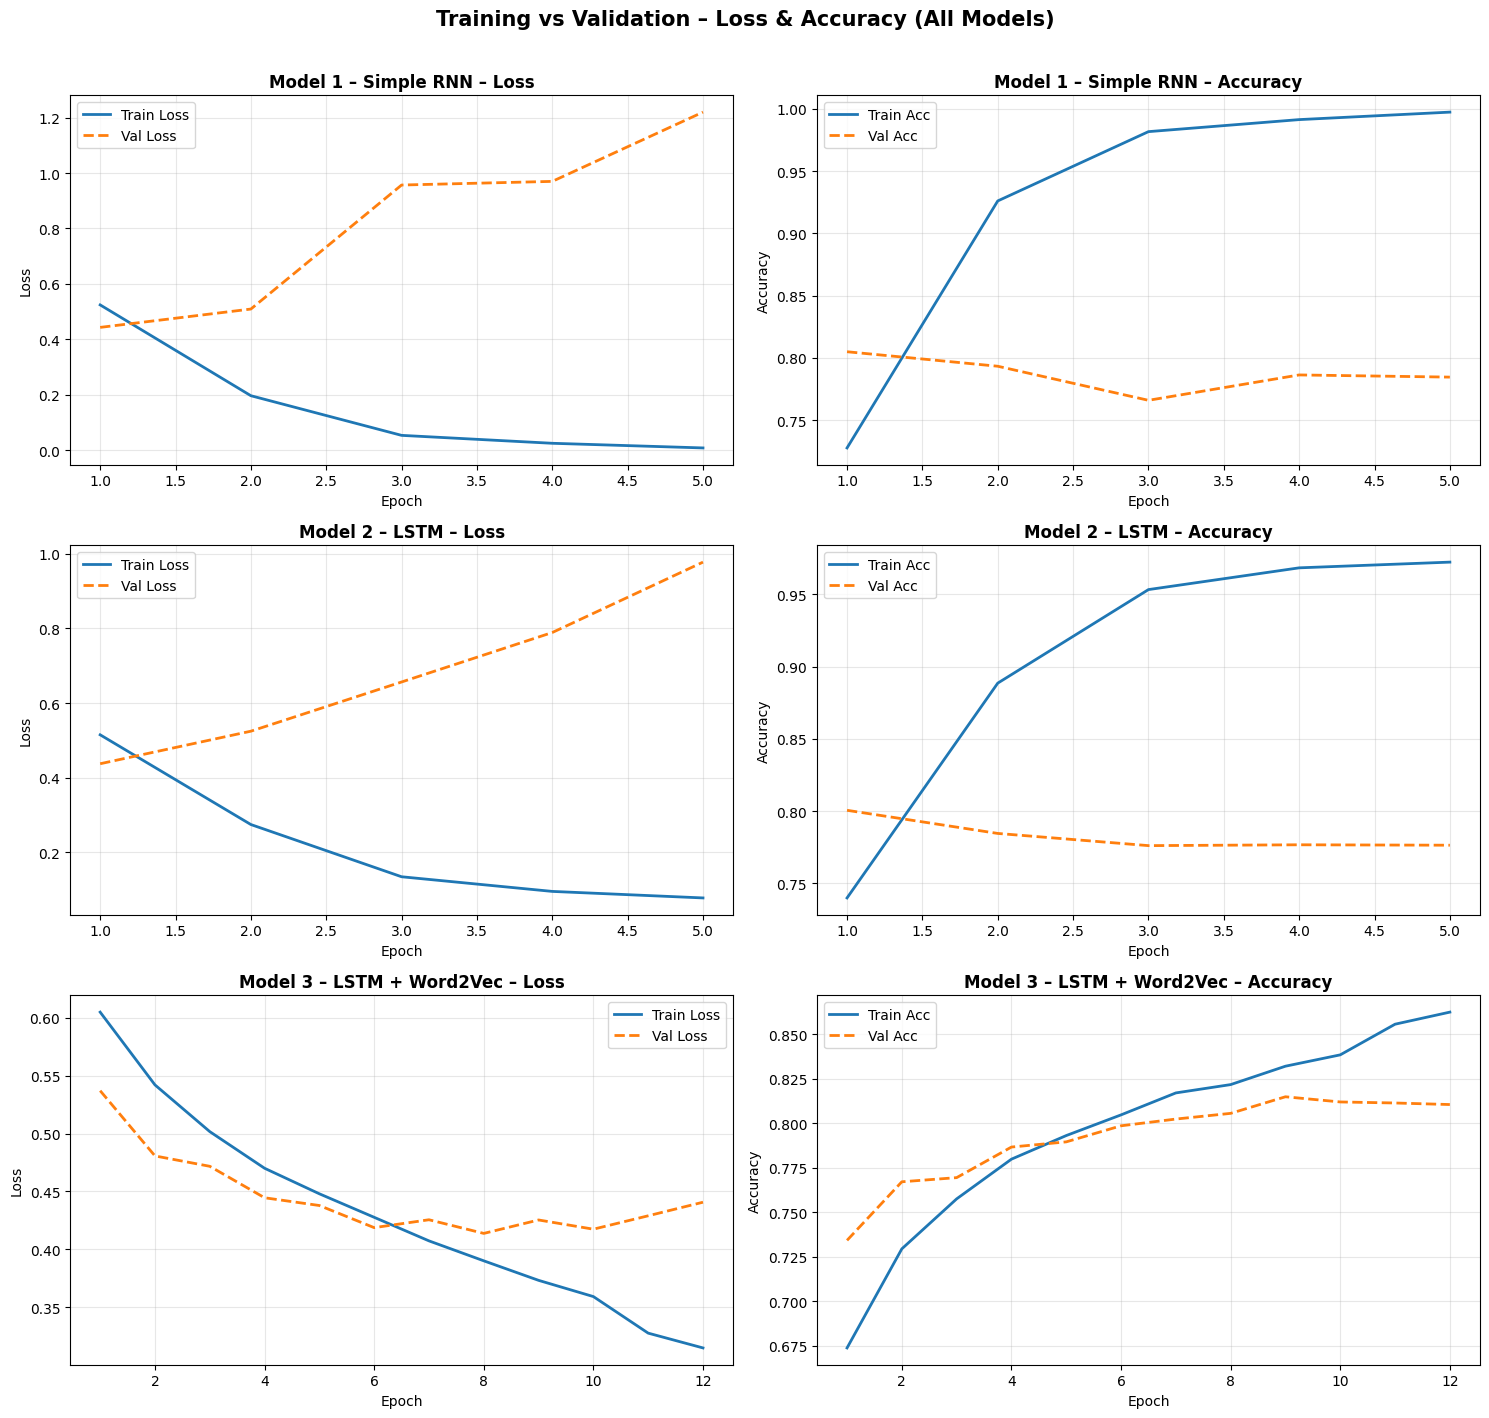

In [37]:
def plot_history(history, model_name, ax_loss, ax_acc):
    """Plot training vs. validation loss and accuracy for a single model."""
    epochs_ran = range(1, len(history.history['loss']) + 1)

    ax_loss.plot(epochs_ran, history.history['loss'],     label='Train Loss', linewidth=2)
    ax_loss.plot(epochs_ran, history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    ax_loss.set_title(f'{model_name} – Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(epochs_ran, history.history['accuracy'],     label='Train Acc', linewidth=2)
    ax_acc.plot(epochs_ran, history.history['val_accuracy'], label='Val Acc',   linewidth=2, linestyle='--')
    ax_acc.set_title(f'{model_name} – Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
plot_history(history_rnn,  'Model 1 – Simple RNN',      axes[0][0], axes[0][1])
plot_history(history_lstm, 'Model 2 – LSTM',             axes[1][0], axes[1][1])
plot_history(history_w2v,  'Model 3 – LSTM + Word2Vec',  axes[2][0], axes[2][1])

plt.suptitle('Training vs Validation – Loss & Accuracy (All Models)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [38]:
# Evaluate all models on the held-out test set
models_info = [
    ('Model 1 – Simple RNN',       rnn_model,      rnn_train_time),
    ('Model 2 – LSTM',             lstm_model,     lstm_train_time),
    ('Model 3 – LSTM + Word2Vec',  lstm_w2v_model, w2v_train_time),
]

results = {}
for name, model, t_time in models_info:
    loss, acc   = model.evaluate(X_test_pad, y_test_cat, verbose=0)
    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    results[name] = {'accuracy': acc, 'loss': loss, 'y_pred': y_pred, 'train_time': t_time}
    print(f"{name}: Acc = {acc:.4f} | Loss = {loss:.4f} | Train Time = {t_time:.1f}s")

Model 1 – Simple RNN: Acc = 0.7900 | Loss = 0.4513 | Train Time = 54.5s
Model 2 – LSTM: Acc = 0.7876 | Loss = 0.4404 | Train Time = 165.3s
Model 3 – LSTM + Word2Vec: Acc = 0.7979 | Loss = 0.4262 | Train Time = 244.7s


In [39]:
for name, res in results.items():
    print(f"\n{'='*65}")
    print(f" {name}")
    print('='*65)
    print(classification_report(y_test, res['y_pred'], target_names=CLASS_NAMES))


 Model 1 – Simple RNN
               precision    recall  f1-score   support

Not Sarcastic       0.76      0.87      0.81      2997
    Sarcastic       0.83      0.70      0.76      2727

     accuracy                           0.79      5724
    macro avg       0.80      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724


 Model 2 – LSTM
               precision    recall  f1-score   support

Not Sarcastic       0.77      0.85      0.81      2997
    Sarcastic       0.81      0.72      0.76      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.78      0.79      5724
 weighted avg       0.79      0.79      0.79      5724


 Model 3 – LSTM + Word2Vec
               precision    recall  f1-score   support

Not Sarcastic       0.77      0.88      0.82      2997
    Sarcastic       0.84      0.71      0.77      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.79      0.79

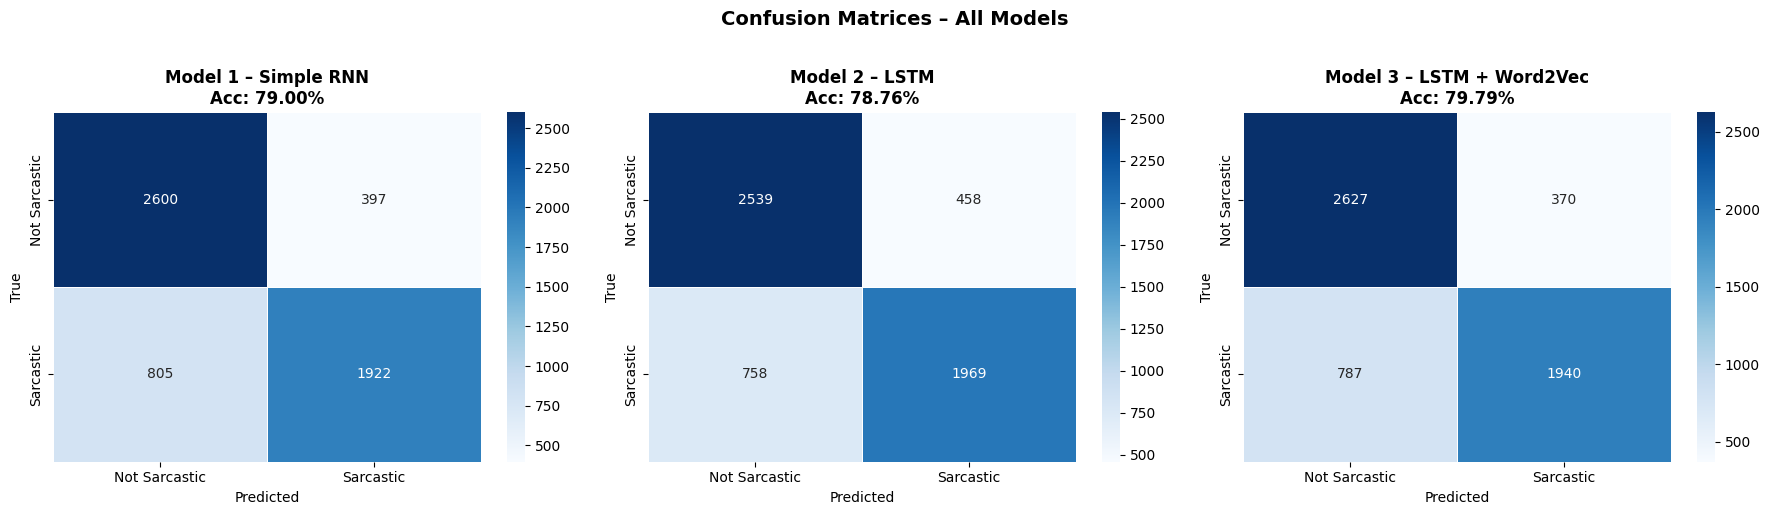

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5
    )
    ax.set_title(f'{name}\nAcc: {res["accuracy"]*100:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

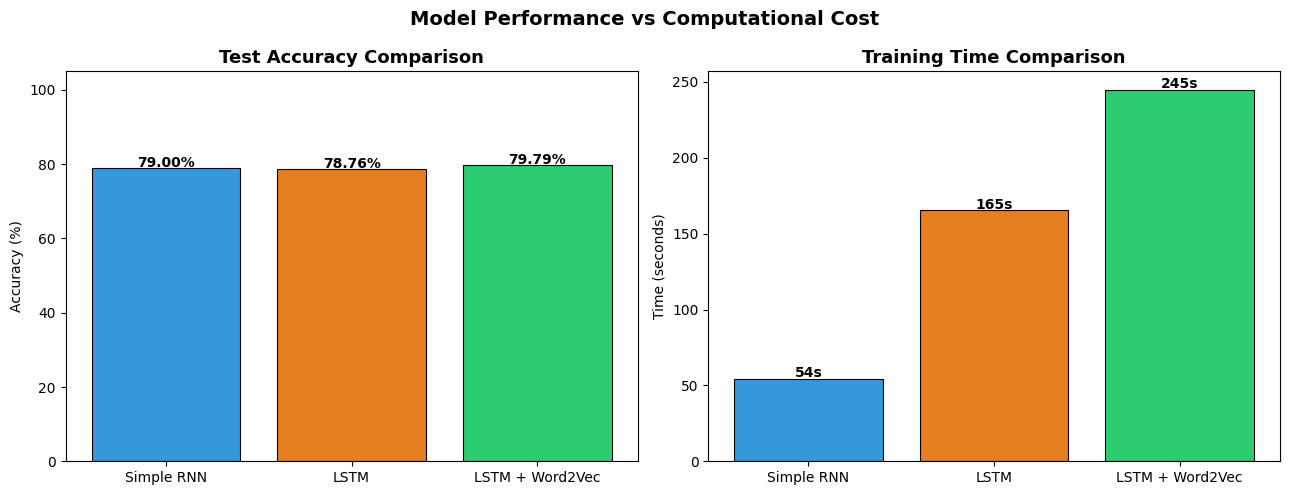

In [41]:
model_names = [n.split('–')[1].strip() for n in results.keys()]
accuracies  = [v['accuracy'] * 100 for v in results.values()]
train_times = [v['train_time'] for v in results.values()]
bar_colors  = ['#3498DB', '#E67E22', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(model_names, accuracies, color=bar_colors, edgecolor='black', linewidth=0.8)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')

axes[1].bar(model_names, train_times, color=bar_colors, edgecolor='black', linewidth=0.8)
for i, v in enumerate(train_times):
    axes[1].text(i, v + 1, f'{v:.0f}s', ha='center', fontweight='bold')
axes[1].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Time (seconds)')

plt.suptitle('Model Performance vs Computational Cost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 5: Error Analysis

In [42]:
# Analyse misclassified headlines using the best model (Model 3 – LSTM + Word2Vec)
best_preds = results['Model 3 – LSTM + Word2Vec']['y_pred']

error_df = pd.DataFrame({
    'original_headline': X_test,
    'clean_headline':    [clean_headline(h) for h in X_test],
    'true_label':        [CLASS_NAMES[i] for i in y_test],
    'pred_label':        [CLASS_NAMES[i] for i in best_preds]
})

misclassified = error_df[error_df['true_label'] != error_df['pred_label']].reset_index(drop=True)

print(f"Total misclassified   : {len(misclassified)} / {len(error_df)}")
print(f"Misclassification rate: {len(misclassified)/len(error_df)*100:.2f}%\n")

print("=" * 75)
print(" Sample Misclassified Headlines (Model 3 – LSTM + Word2Vec)")
print("=" * 75)
for i, row in misclassified.head(5).iterrows():
    print(f"\n[Example {i+1}]")
    print(f"  Headline  : {row['original_headline'][:120]}")
    print(f"  Cleaned   : {row['clean_headline'][:100]}")
    print(f"  True Label: {row['true_label'].upper()}")
    print(f"  Predicted : {row['pred_label'].upper()}")

Total misclassified   : 1157 / 5724
Misclassification rate: 20.21%

 Sample Misclassified Headlines (Model 3 – LSTM + Word2Vec)

[Example 1]
  Headline  : group christie campaign deserter found forest
  Cleaned   : group christie campaign deserter found forest
  True Label: SARCASTIC
  Predicted : NOT SARCASTIC

[Example 2]
  Headline  : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
  Cleaned   : democratic congressman protest trump environmental policy bringing endangered red wolf state union g
  True Label: SARCASTIC
  Predicted : NOT SARCASTIC

[Example 3]
  Headline  : rex tillerson call report ouster laughable
  Cleaned   : rex tillerson call report ouster laughable
  True Label: NOT SARCASTIC
  Predicted : SARCASTIC

[Example 4]
  Headline  : prayer answered random series event cold uncaring universe
  Cleaned   : prayer answered random series event cold uncaring universe
  True Label: SARCASTIC
  Predicted : NOT SARCASTI

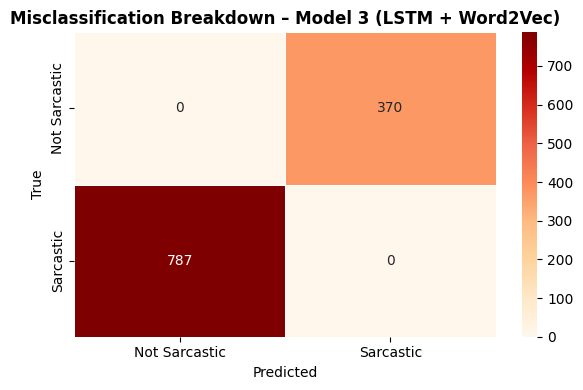


Key Observations:
  • Sarcastic headlines often use irony and exaggeration with words that
    appear genuine, making it hard for static GloVe vectors to distinguish
    sarcasm from sincere statements.
  • Non-sarcastic headlines that use dramatic or hyperbolic language may
    be falsely predicted as sarcastic.
  • Short headlines lose crucial context after stopword removal and
    lemmatisation, increasing misclassification for borderline cases.



In [43]:
# Misclassification breakdown: which class gets confused with which
misclass_matrix = pd.crosstab(
    misclassified['true_label'],
    misclassified['pred_label'],
    rownames=['True'],
    colnames=['Predicted']
)

plt.figure(figsize=(6, 4))
sns.heatmap(misclass_matrix, annot=True, fmt='d', cmap='OrRd', linewidths=0.5)
plt.title('Misclassification Breakdown – Model 3 (LSTM + Word2Vec)', fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Key Observations:
  • Sarcastic headlines often use irony and exaggeration with words that
    appear genuine, making it hard for static GloVe vectors to distinguish
    sarcasm from sincere statements.
  • Non-sarcastic headlines that use dramatic or hyperbolic language may
    be falsely predicted as sarcastic.
  • Short headlines lose crucial context after stopword removal and
    lemmatisation, increasing misclassification for borderline cases.
""")

In [44]:
# Model complexity vs performance summary table
summary_rows = []
for name, model, t_time in models_info:
    total_params     = model.count_params()
    trainable_params = sum(tf.size(v).numpy() for v in model.trainable_variables)
    acc = results[name]['accuracy'] * 100
    summary_rows.append({
        'Model':           name.split('–')[1].strip(),
        'Total Params':    f'{total_params:,}',
        'Trainable':       f'{trainable_params:,}',
        'Test Acc (%)':    f'{acc:.2f}',
        'Train Time (s)':  f'{t_time:.1f}'
    })

complexity_df = pd.DataFrame(summary_rows)
print("Model Complexity vs Performance:")
print(complexity_df.to_string(index=False))

Model Complexity vs Performance:
          Model Total Params Trainable Test Acc (%) Train Time (s)
     Simple RNN    2,576,642 2,576,642        79.00           54.5
           LSTM    2,745,282 2,745,282        78.76          165.3
LSTM + Word2Vec    2,170,946   170,946        79.79          244.7


In [45]:
print("""
Potential Improvements for Sarcasm Detection:
─────────────────────────────────────────────
1. Use Bidirectional LSTM to capture both left and right context,
   which is important for understanding ironic phrasing.
2. Fine-tune the GloVe embedding layer (trainable=True) after initial
   convergence to adapt vectors to the sarcasm detection domain.
3. Incorporate Attention mechanisms to highlight sarcasm-bearing words
   within a headline.
4. Experiment with transformer-based models (e.g., BERT, RoBERTa) that
   capture contextual semantics beyond static word embeddings.
5. Apply data augmentation (back-translation, synonym replacement) to
   increase training diversity.
6. Tune hyperparameters (LSTM units, dropout rate, learning rate) using
   Keras Tuner for optimal configuration.
""")


Potential Improvements for Sarcasm Detection:
─────────────────────────────────────────────
1. Use Bidirectional LSTM to capture both left and right context,
   which is important for understanding ironic phrasing.
2. Fine-tune the GloVe embedding layer (trainable=True) after initial
   convergence to adapt vectors to the sarcasm detection domain.
3. Incorporate Attention mechanisms to highlight sarcasm-bearing words
   within a headline.
4. Experiment with transformer-based models (e.g., BERT, RoBERTa) that
   capture contextual semantics beyond static word embeddings.
5. Apply data augmentation (back-translation, synonym replacement) to
   increase training diversity.
6. Tune hyperparameters (LSTM units, dropout rate, learning rate) using
   Keras Tuner for optimal configuration.



---
## Section 6: Real-Time Prediction Interface (Gradio GUI)

In [46]:
import gradio as gr

def predict_sarcasm(headline_text: str, model_choice: str) -> str:
    """Preprocess the user's headline and return a sarcasm prediction."""
    if not headline_text.strip():
        return "Please enter a headline."

    model_map = {
        'Simple RNN':      rnn_model,
        'LSTM':            lstm_model,
        'LSTM + Word2Vec': lstm_w2v_model
    }
    chosen_model = model_map[model_choice]

    cleaned    = clean_headline(headline_text)
    sequence   = tokenizer.texts_to_sequences([cleaned])
    padded     = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    pred_probs = chosen_model.predict(padded, verbose=0)[0]
    pred_class = int(np.argmax(pred_probs))
    label      = CLASS_NAMES[pred_class]
    confidence = pred_probs[pred_class] * 100

    emoji_map = {'Not Sarcastic': '😐', 'Sarcastic': '😏'}
    emoji = emoji_map.get(label, '')

    breakdown = '\n'.join(
        [f"  {CLASS_NAMES[i]:15s}: {pred_probs[i]*100:.2f}%" for i in range(NUM_CLASSES)]
    )

    return (
        f"Prediction : {emoji} {label.upper()}\n"
        f"Confidence : {confidence:.2f}%\n\n"
        f"Class Probabilities:\n{breakdown}"
    )


demo = gr.Interface(
    fn=predict_sarcasm,
    inputs=[
        gr.Textbox(
            lines=2,
            placeholder="Enter a news headline here…",
            label="Headline Text"
        ),
        gr.Dropdown(
            choices=['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
            value='LSTM + Word2Vec',
            label="Select Model"
        )
    ],
    outputs=gr.Textbox(label="Prediction Result", lines=7),
    title="🎭 News Headline Sarcasm Detector",
    description="Enter a news headline and choose a model to predict whether it is sarcastic or not.",
    examples=[
        ["Scientists discover that eating more food makes you less hungry",              "LSTM + Word2Vec"],
        ["New study links exercise to improved health outcomes",                         "LSTM + Word2Vec"],
        ["Area man confident he knows more about vaccines than actual doctors",          "LSTM + Word2Vec"],
        ["Government announces record spending on education this year",                  "LSTM"],
        ["Nation's experts agree that everything is fine, nothing to worry about",       "Simple RNN"]
    ],
    flagging_mode="never"
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa7d4c794ce4975213.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
